# How 🤗 Transformers solve tasks

在Transformers, what can they do?中，您了解了自然语言处理（NLP）、语音和音频、计算机视觉任务以及它们的一些重要应用。本页将仔细探讨模型如何解决这些任务，并解释其内部原理。解决给定任务的方法有很多，某些模型可能会采用特定的技术，甚至从新的角度来处理任务，但对于 Transformer 模型来说，其总体思路是相同的。由于其灵活的架构，大多数模型都是编码器、解码器或编码器 - 解码器结构的变体。

在深入探讨具体的架构变体之前，先理解大多数任务都遵循类似的模式是有帮助的：输入数据通过模型进行处理，然后对输出进行特定任务的解读。不同之处在于数据的准备方式、所使用的模型架构变体以及输出的处理方式。

为了解释任务是如何解决的，我们将详细探讨模型内部的运作机制，以输出有用的预测结果。我们将涵盖以下模型及其对应的任务：

- BERT: 用于自然语言处理任务（如文本分类、token分类和问答）的 BERT 编码器
- GPT2: 用于诸如文本生成等自然语言处理任务的 GPT2，它使用解码器
- BERT: 用于诸如摘要和翻译等自然语言处理任务的 BART 编码器 - 解码器


在继续之前，了解原始 Transformer 架构的一些基础知识会很有帮助。了解编码器、解码器和注意力机制的工作原理将有助于您理解不同的 Transformer 模型是如何工作的。请务必查看上一节以获取更多信息！

## Transformer models for language

语言模型是现代自然语言处理的核心。它们旨在通过学习文本中单词或标记之间的统计模式和关系来理解和生成人类语言。

Transformer 最初是为机器翻译而设计的，从那以后，它已成为解决所有人工智能任务的默认架构。有些任务适合 Transformer 的编码器结构，而有些任务则更适合解码器。还有一些任务则同时利用了 Transformer 的编码器 - 解码器结构。

### How language models work

语言模型通过训练来预测给定周围词语上下文的某个词出现的概率而发挥作用。这使它们具备了对语言的基础理解能力，能够推广应用于其他任务。

训练一个transformer模型主要有两种方法：

1. Masked language modeling（MLM）：像 BERT 这样的编码器模型所采用的方法，它会随机遮蔽输入中的某些标记，并训练模型根据上下文预测原始标记。这使得模型能够学习双向上下文（即同时考虑被遮蔽词之前和之后的词）。
2. Causal language modeling（CLM）：像 GPT 这样的**解码器模型**所采用的方法，它根据序列中所有先前的标记来预测下一个标记。该模型只能使用来自左侧（先前标记）的上下文来预测下一个标记。

### Types of language models

在 Transformers 库中，语言模型通常分为三大架构类别：

1. Encoder-only models （如 BERT）：这些模型采用双向方法从两个方向理解上下文。它们最适合需要对文本进行深度理解的任务，例如分类、命名实体识别和问答。
2. Decoder-only models（如 GPT、Llama）：这些模型从左到右处理文本，在文本生成任务方面表现出色。它们能够根据提示完成句子、撰写文章，甚至生成代码。
3. Encoder-decoder models（如 T5、BART）：这些模型结合了两种方法，使用编码器来理解输入，使用解码器来生成输出。它们在诸如翻译、摘要和问答之类的序列到序列任务中表现出色。

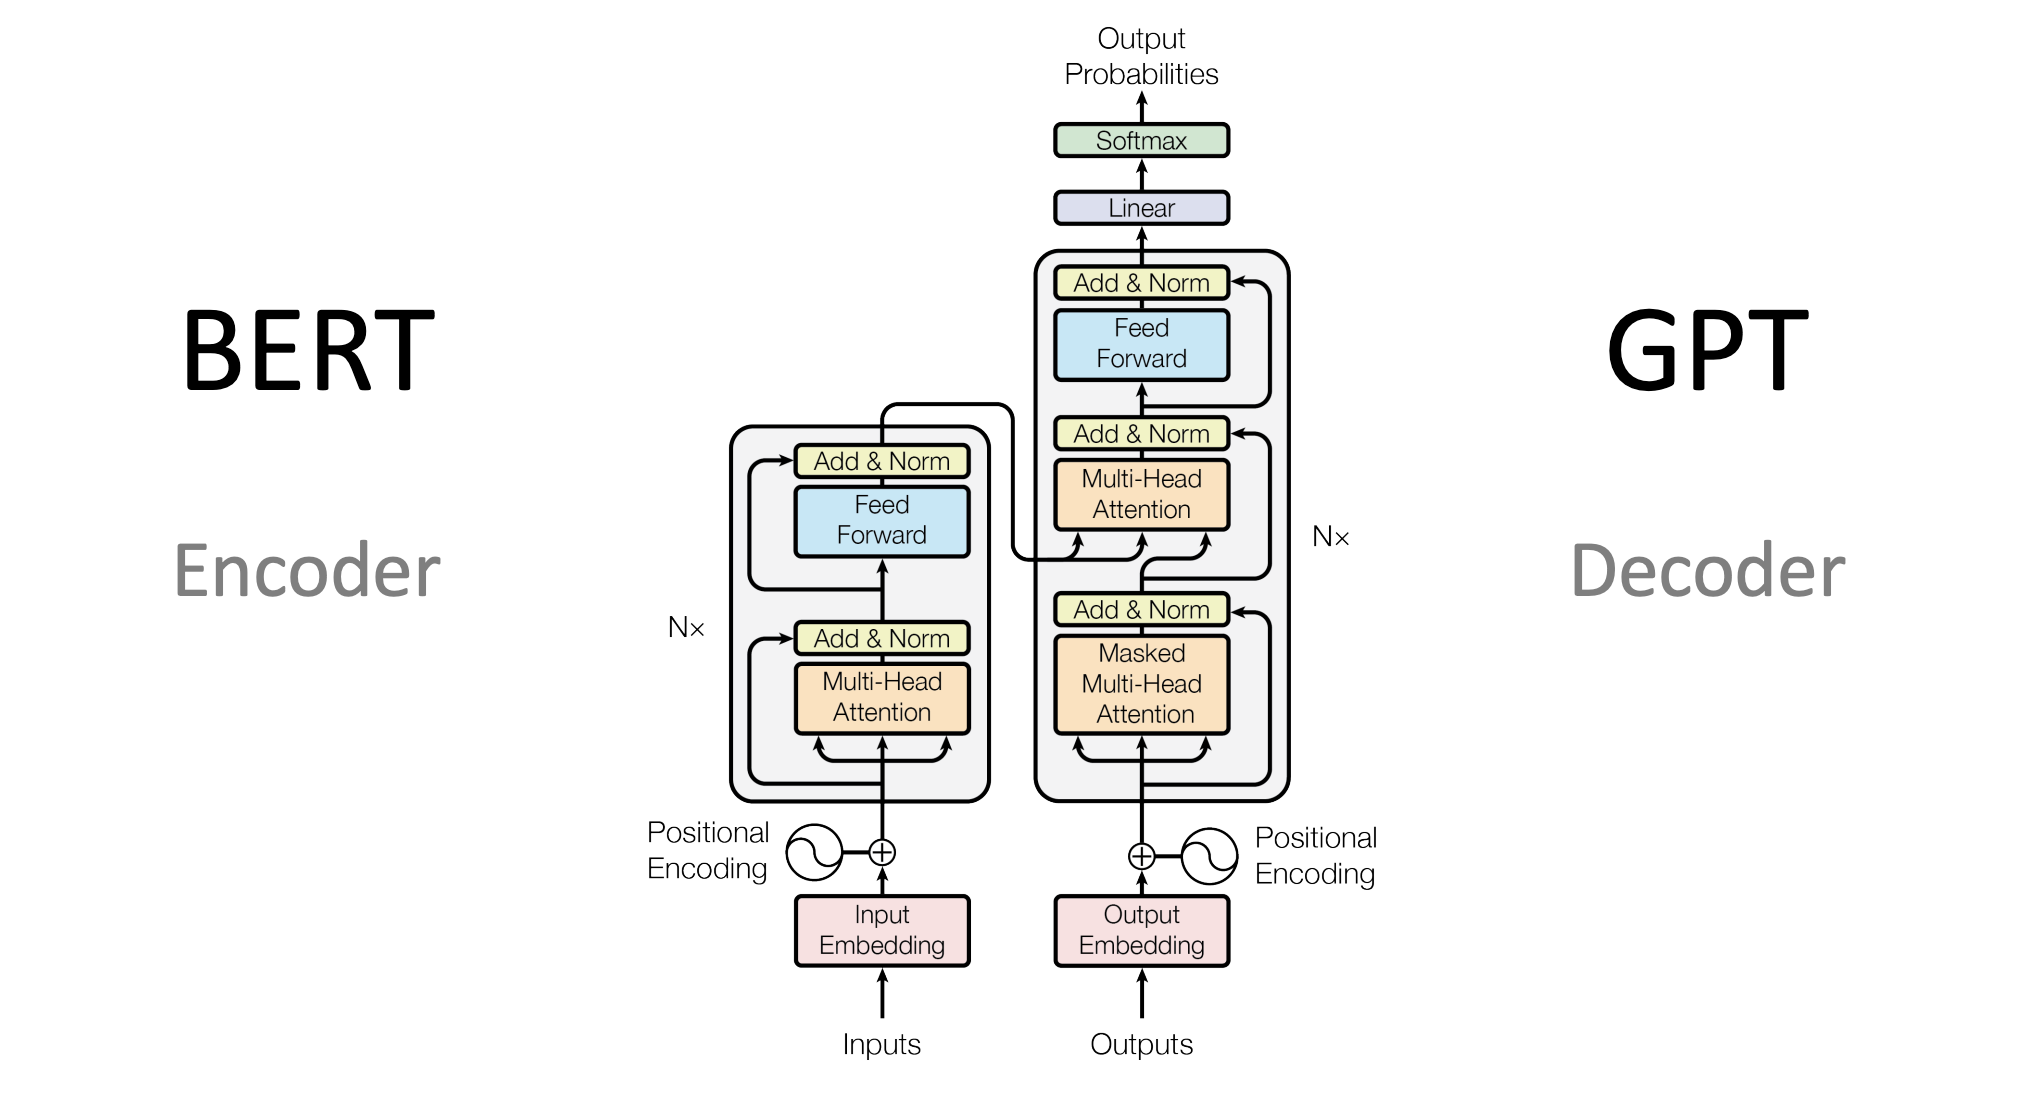

正如我们在上一节中所介绍的，语言模型通常在大量文本数据上以自监督的方式（无需人工标注）进行预训练，然后在特定任务上进行微调。这种方法被称为迁移学习，它使得这些模型能够利用相对少量的任务特定数据适应许多不同的自然语言处理任务。

在接下来的部分中，我们将探讨具体的模型架构以及它们在语音、视觉和文本等不同领域的各种任务中的应用。

了解 Transformer 架构的哪一部分（编码器、解码器或两者）最适合特定的自然语言处理任务，是选择正确模型的关键。**通常，需要双向上下文的任务使用编码器，生成文本的任务使用解码器，将一个序列转换为另一个序列的任务使用编码器 - 解码器。**

### Text generation

文本生成涉及根据提示或输入创建连贯且符合上下文的文本。


GPT-2 是一个仅含解码器的模型，它在大量文本上进行了预训练。给定一个提示，它能够生成令人信服（尽管并非总是真实的！）的文本，并且尽管没有经过专门训练，它还能完成诸如问答之类的其他自然语言处理任务。

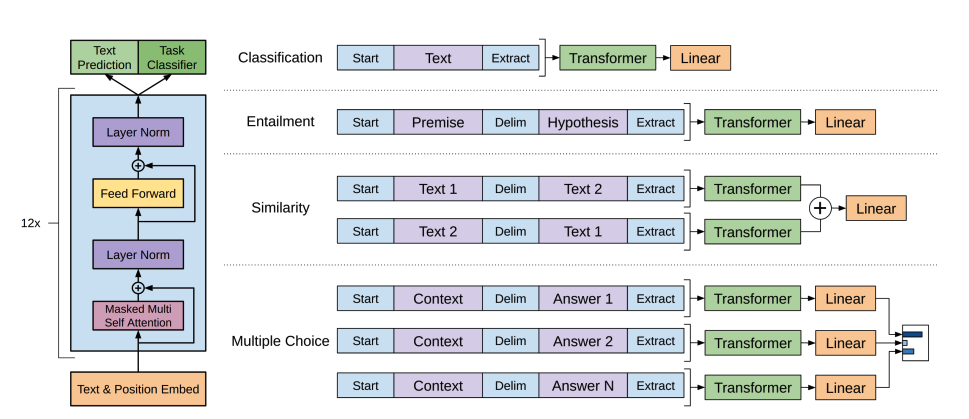

1. GPT-2 使用字节对编码（BPE）对单词进行分词，并生成标记嵌入。位置编码被添加到标记嵌入中，以指示序列中每个标记的位置。输入嵌入通过多个解码器块传递，以输出一些最终的隐藏状态。在每个解码器块内，GPT-2 使用掩码自注意力层，这意味着 GPT-2 无法关注未来的标记。它只能关注左侧的标记。这与 BERT 的 [mask] 标记不同，因为在掩码自注意力中，使用注意力掩码将未来标记的分数设置为 0。
2. 解码器的输出被传递给语言建模头( language modeling head)，该头执行线性变换，将隐藏状态转换为对数几率。标签是序列中的下一个标记，通过将对数几率向右移动一位来生成。在移位后的对数几率和标签之间计算交叉熵损失，以输出下一个最有可能的标记。